# 🏠 Ames Housing — Codificación de Variables Categóricas para Regresión

Este cuadernillo transforma las **43 variables de texto** del dataset de Ames, Iowa, en representaciones numéricas que pueden ser usadas directamente en modelos de regresión.

## Estrategias de codificación que usaremos

| Tipo de variable | Estrategia | Ejemplo |
|---|---|---|
| Calidad ordinal (Ex > Gd > TA > Fa > Po) | **Mapeo ordinal** | `Exter Qual`, `Kitchen Qual` |
| Funcionalidad ordinal | **Mapeo ordinal** | `Functional`, `Garage Finish` |
| Binaria (Y/N) | **Mapeo binario (0/1)** | `Central Air` |
| Nominal (sin orden) | **One-Hot Encoding** | `Garage Type`, `Foundation` |
| Alta cardinalidad | **Target Encoding** | `Neighborhood` |

---

## 1. Carga de datos y exploración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('train.csv')
print(f'Dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Variable objetivo: SalePrice  |  Media: ${df["SalePrice"].mean():,.0f}')

Dataset: 2197 filas × 82 columnas
Variable objetivo: SalePrice  |  Media: $182,377


In [2]:
# Separar variables por tipo
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

print(f'Variables categóricas (texto): {len(cat_cols)}')
print(f'Variables numéricas: {len(num_cols)}')
print()

# Nulos en variables categóricas
nulls = df[cat_cols].isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(1)
null_df = pd.DataFrame({'Nulos': nulls, '% Nulos': nulls_pct, 'Únicos': df[cat_cols].nunique()})
null_df = null_df[null_df['Nulos'] > 0]
print('Variables con valores nulos:')
print(null_df.to_string())

Variables categóricas (texto): 43
Variables numéricas: 39

Variables con valores nulos:
                Nulos  % Nulos  Únicos
Alley            2054     93.5       2
Bsmt Cond          67      3.0       5
Bsmt Exposure      69      3.1       4
Bsmt Qual          67      3.0       5
BsmtFin Type 1     67      3.0       6
BsmtFin Type 2     68      3.1       6
Electrical          1      0.0       5
Fence            1778     80.9       4
Fireplace Qu     1066     48.5       5
Garage Cond       122      5.6       5
Garage Finish     122      5.6       3
Garage Qual       122      5.6       5
Garage Type       120      5.5       6
Mas Vnr Type     1329     60.5       4
Misc Feature     2117     96.4       5
Pool QC          2185     99.5       4


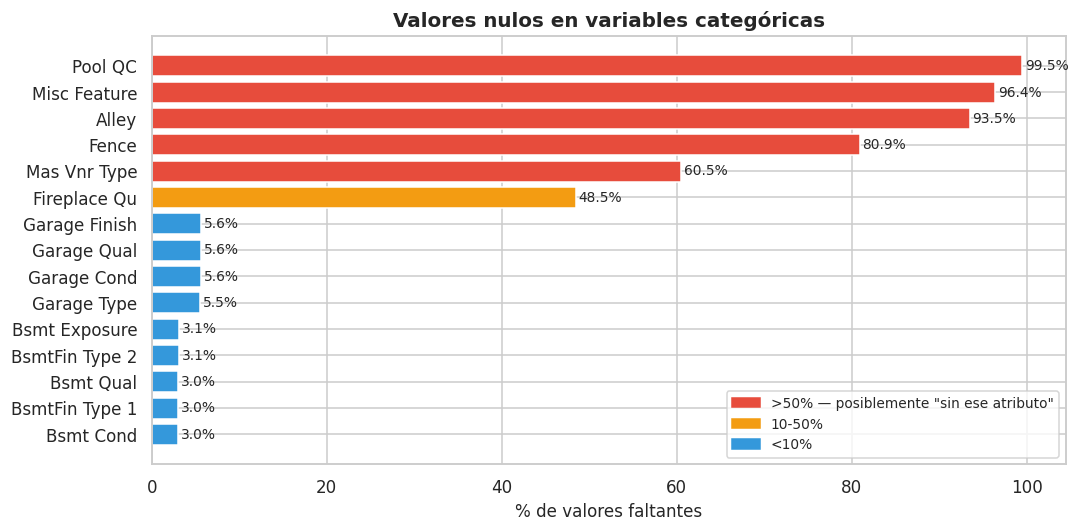

In [3]:
# Visualizar nulos en variables categóricas
fig, ax = plt.subplots(figsize=(10, 5))
nulls_pct_sorted = nulls_pct[nulls_pct > 0].sort_values()
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#3498db' for v in nulls_pct_sorted]
bars = ax.barh(nulls_pct_sorted.index, nulls_pct_sorted.values, color=colors)
ax.set_xlabel('% de valores faltantes', fontsize=11)
ax.set_title('Valores nulos en variables categóricas', fontsize=13, fontweight='bold')
for bar, val in zip(bars, nulls_pct_sorted.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
patches = [
    mpatches.Patch(color='#e74c3c', label='>50% — posiblemente "sin ese atributo"'),
    mpatches.Patch(color='#f39c12', label='10-50%'),
    mpatches.Patch(color='#3498db', label='<10%')
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## 2. Tratamiento de valores nulos

> En este dataset, muchos `NaN` en variables categóricas **no son datos faltantes** sino que significan "la vivienda no tiene ese atributo" (ej. `Fireplace Qu = NaN` → sin chimenea). Los rellenamos con `'None'`.

In [4]:
df_enc = df.copy()

# Variables donde NaN = "ausencia del atributo"
none_cols = [
    'Alley', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1',
    'BsmtFin Type 2', 'Fireplace Qu', 'Garage Type', 'Garage Finish',
    'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature', 'Mas Vnr Type'
]
for col in none_cols:
    df_enc[col] = df_enc[col].fillna('None')

# Variables donde NaN = moda (dato realmente faltante)
mode_cols = ['Electrical', 'MS Zoning', 'Utilities', 'Functional', 'Sale Type']
for col in mode_cols:
    df_enc[col] = df_enc[col].fillna(df_enc[col].mode()[0])

remaining_nulls = df_enc[cat_cols].isnull().sum().sum()
print(f'Nulos restantes en variables categóricas: {remaining_nulls}')

Nulos restantes en variables categóricas: 0


## 3. Codificación Ordinal — Variables de Calidad

Variables con escala clara de calidad usan un mapa numérico:
`None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5`

In [5]:
# Escala de calidad estándar
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

quality_cols = [
    'Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
    'Heating QC', 'Kitchen Qual', 'Fireplace Qu',
    'Garage Qual', 'Garage Cond', 'Pool QC'
]

for col in quality_cols:
    df_enc[col] = df_enc[col].map(quality_map)

# Verificar
print('Muestra después de codificación de calidad:')
print(df_enc[quality_cols].head(3).to_string())

Muestra después de codificación de calidad:
   Exter Qual  Exter Cond  Bsmt Qual  Bsmt Cond  Heating QC  Kitchen Qual  Fireplace Qu  Garage Qual  Garage Cond  Pool QC
0           4           3          4          3           5             4             0            3            3        0
1           4           3          4          3           4             4             3            3            3        0
2           3           3          3          3           4             4             4            3            3        0


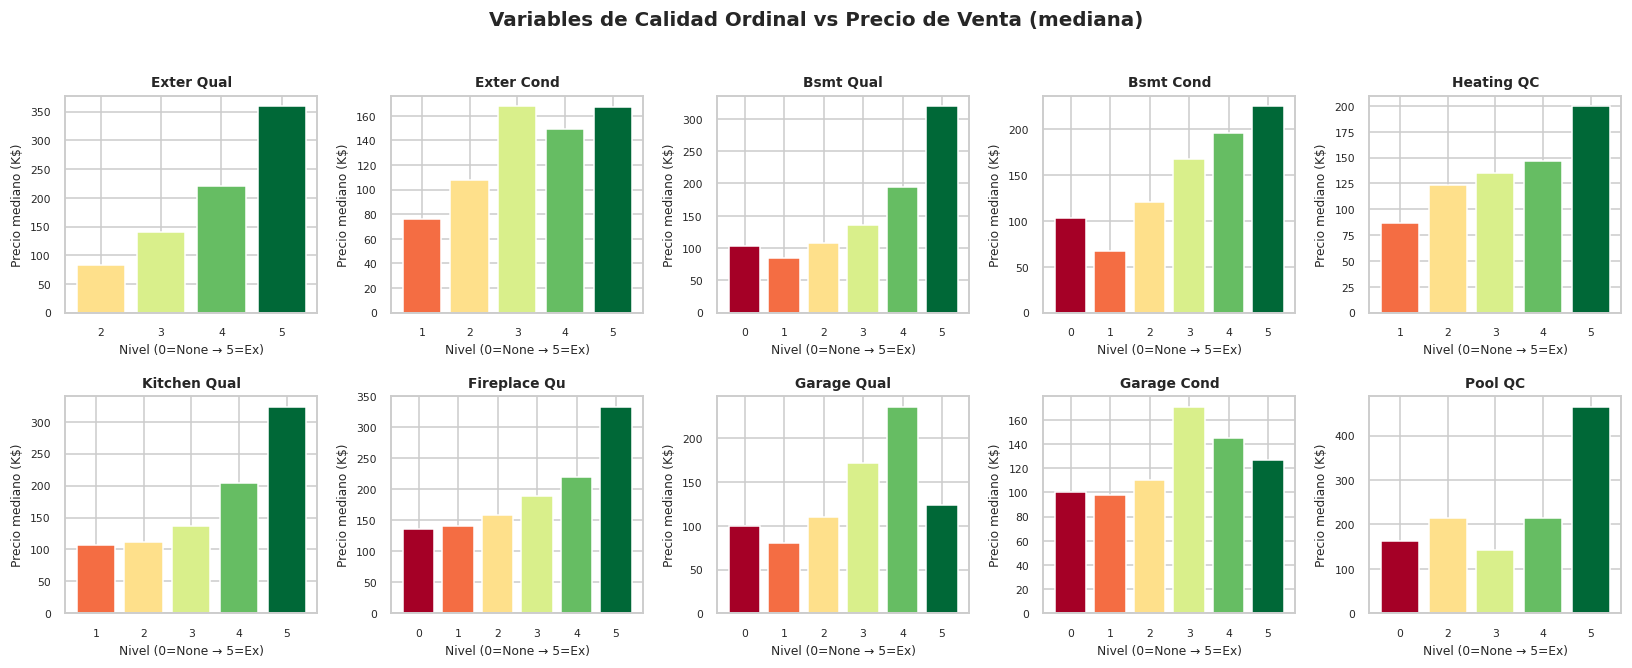

In [6]:
# Visualizar correlación de variables de calidad con SalePrice
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(quality_cols):
    data = df_enc.dropna(subset=[col])
    grouped = data.groupby(col)['SalePrice'].median().reset_index()
    axes[i].bar(grouped[col].astype(str), grouped['SalePrice'] / 1000,
                color=plt.cm.RdYlGn(grouped[col] / 5.0))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Nivel (0=None → 5=Ex)', fontsize=8)
    axes[i].set_ylabel('Precio mediano (K$)', fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Variables de Calidad Ordinal vs Precio de Venta (mediana)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Codificación Ordinal — Variables Funcionales y de Exposición

In [7]:
# Funcionalidad de la vivienda (de más deterioro a típica)
functional_map = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,
                  'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}
df_enc['Functional'] = df_enc['Functional'].map(functional_map)

# Exposición del sótano
bsmt_exp_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
df_enc['Bsmt Exposure'] = df_enc['Bsmt Exposure'].map(bsmt_exp_map)

# Tipo de acabado del sótano
bsmtfin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
df_enc['BsmtFin Type 1'] = df_enc['BsmtFin Type 1'].map(bsmtfin_map)
df_enc['BsmtFin Type 2'] = df_enc['BsmtFin Type 2'].map(bsmtfin_map)

# Acabado del garaje
garage_finish_map = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
df_enc['Garage Finish'] = df_enc['Garage Finish'].map(garage_finish_map)

# Forma del lote (de regular a irregular)
lot_shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
df_enc['Lot Shape'] = df_enc['Lot Shape'].map(lot_shape_map)

# Pendiente del terreno
land_slope_map = {'Gtl': 1, 'Mod': 2, 'Sev': 3}
df_enc['Land Slope'] = df_enc['Land Slope'].map(land_slope_map)

# Acceso vial
street_map = {'Grvl': 0, 'Pave': 1}
df_enc['Street'] = df_enc['Street'].map(street_map)

# Callejón
alley_map = {'None': 0, 'Grvl': 1, 'Pave': 2}
df_enc['Alley'] = df_enc['Alley'].map(alley_map)

# Entrada de coches pavimentada
paved_map = {'N': 0, 'P': 1, 'Y': 2}
df_enc['Paved Drive'] = df_enc['Paved Drive'].map(paved_map)

# Barda/Cerca
fence_map = {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}
df_enc['Fence'] = df_enc['Fence'].map(fence_map)

print('✅ Variables ordinales especiales codificadas.')

# Tabla resumen de mapeos
resumen = {
    'Functional': 'Sal(1) → Typ(8)',
    'Bsmt Exposure': 'None(0) → Gd(4)',
    'BsmtFin Type 1/2': 'None(0) → GLQ(6)',
    'Garage Finish': 'None(0) → Fin(3)',
    'Lot Shape': 'IR3(1) → Reg(4)',
    'Land Slope': 'Gtl(1) → Sev(3)',
    'Street': 'Grvl(0) → Pave(1)',
    'Alley': 'None(0) → Pave(2)',
    'Paved Drive': 'N(0) → Y(2)',
    'Fence': 'None(0) → GdPrv(4)'
}
print()
print('Resumen de mapeos ordinales:')
for k, v in resumen.items():
    print(f'  {k:<22} : {v}')

✅ Variables ordinales especiales codificadas.

Resumen de mapeos ordinales:
  Functional             : Sal(1) → Typ(8)
  Bsmt Exposure          : None(0) → Gd(4)
  BsmtFin Type 1/2       : None(0) → GLQ(6)
  Garage Finish          : None(0) → Fin(3)
  Lot Shape              : IR3(1) → Reg(4)
  Land Slope             : Gtl(1) → Sev(3)
  Street                 : Grvl(0) → Pave(1)
  Alley                  : None(0) → Pave(2)
  Paved Drive            : N(0) → Y(2)
  Fence                  : None(0) → GdPrv(4)


## 5. Codificación Binaria

Central Air → 0/1
Central Air
1    2048
0     149
Name: count, dtype: int64


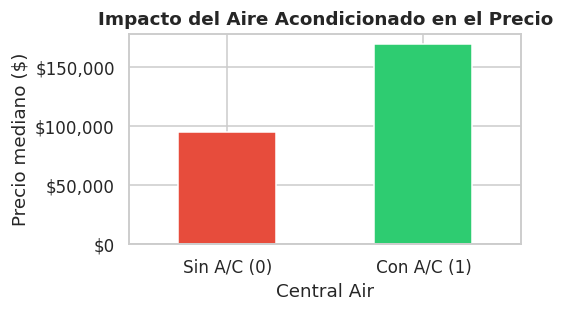

In [8]:
# Central Air: Y=1, N=0
df_enc['Central Air'] = df_enc['Central Air'].map({'Y': 1, 'N': 0})

print('Central Air → 0/1')
print(df_enc['Central Air'].value_counts())

# Visualizar
fig, ax = plt.subplots(figsize=(5, 3))
df_enc.groupby('Central Air')['SalePrice'].median().plot(
    kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_xticklabels(['Sin A/C (0)', 'Con A/C (1)'], rotation=0)
ax.set_ylabel('Precio mediano ($)')
ax.set_title('Impacto del Aire Acondicionado en el Precio', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 6. Target Encoding — Neighborhood (Alta cardinalidad)

Con 28 vecindarios, One-Hot crearía demasiadas columnas dispersas. En su lugar usamos **Target Encoding**: reemplazamos cada vecindario por el precio mediano de sus viviendas.

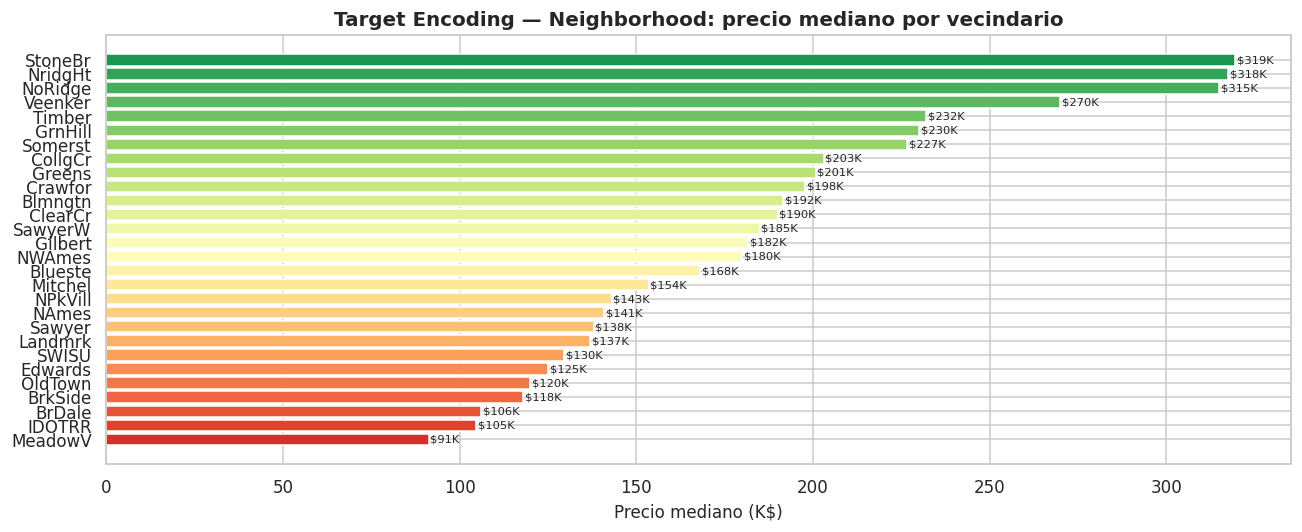


Neighborhood_enc: rango $91,250 — $319,450


In [9]:
neigh_median = df_enc.groupby('Neighborhood')['SalePrice'].median().sort_values()
df_enc['Neighborhood_enc'] = df_enc['Neighborhood'].map(neigh_median)
df_enc.drop(columns=['Neighborhood'], inplace=True)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(neigh_median.index, neigh_median.values / 1000,
               color=plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(neigh_median))))
ax.set_xlabel('Precio mediano (K$)', fontsize=11)
ax.set_title('Target Encoding — Neighborhood: precio mediano por vecindario', 
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, neigh_median.values / 1000):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'${val:.0f}K',
            va='center', fontsize=7.5)
plt.tight_layout()
plt.show()

print(f'\nNeighborhood_enc: rango ${neigh_median.min():,.0f} — ${neigh_median.max():,.0f}')

## 7. One-Hot Encoding — Variables Nominales

Las variables sin orden natural se transforman en columnas binarias (0/1) mediante **One-Hot Encoding**.

In [10]:
nominal_cols = [
    'MS Zoning', 'Land Contour', 'Utilities', 'Lot Config',
    'Condition 1', 'Condition 2', 'Bldg Type', 'House Style',
    'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd',
    'Mas Vnr Type', 'Foundation', 'Heating', 'Electrical',
    'Garage Type', 'Misc Feature', 'Sale Type', 'Sale Condition'
]

n_antes = df_enc.shape[1]
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True, dtype=int)
n_despues = df_enc.shape[1]

print(f'Columnas antes del OHE: {n_antes}')
print(f'Columnas después del OHE: {n_despues}')
print(f'Nuevas columnas generadas: {n_despues - n_antes}')

# Mostrar las nuevas columnas de Garage Type como ejemplo
garage_cols = [c for c in df_enc.columns if 'Garage Type' in c]
print(f'\nColumnas OHE de Garage Type: {garage_cols}')
print(df_enc[garage_cols].head(5).to_string())

Columnas antes del OHE: 82
Columnas después del OHE: 189
Nuevas columnas generadas: 107

Columnas OHE de Garage Type: ['Garage Type_Attchd', 'Garage Type_Basment', 'Garage Type_BuiltIn', 'Garage Type_CarPort', 'Garage Type_Detchd', 'Garage Type_None']
   Garage Type_Attchd  Garage Type_Basment  Garage Type_BuiltIn  Garage Type_CarPort  Garage Type_Detchd  Garage Type_None
0                   0                    0                    0                    0                   1                 0
1                   1                    0                    0                    0                   0                 0
2                   0                    1                    0                    0                   0                 0
3                   1                    0                    0                    0                   0                 0
4                   0                    0                    1                    0                   0                 0


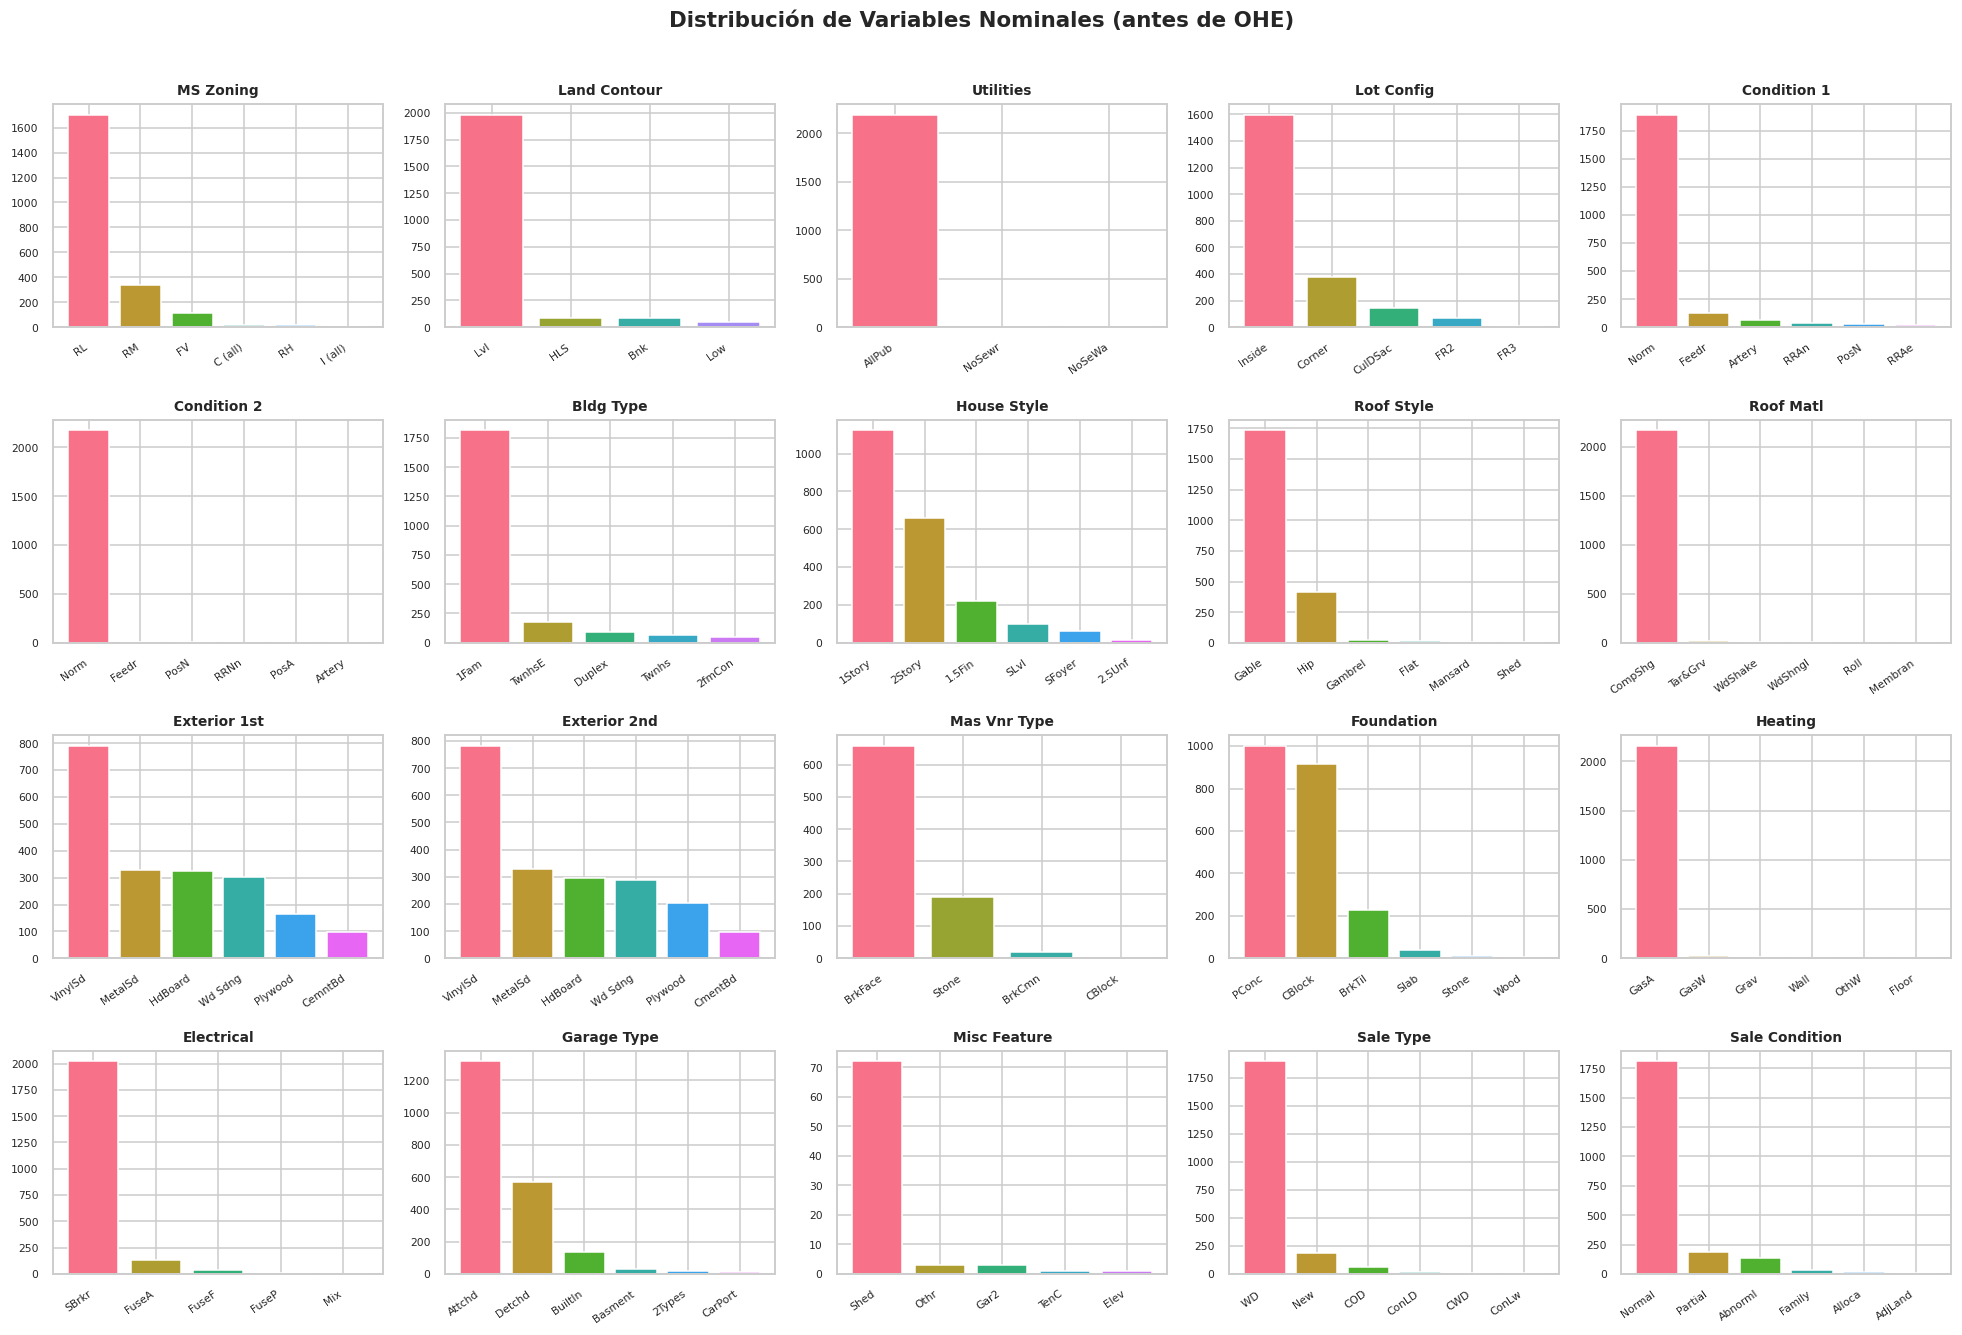

In [11]:
# Visualizar conteo de categorías antes del OHE (para entender la distribución)
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(nominal_cols):
    counts = df[col].value_counts().head(6)
    axes[i].bar(range(len(counts)), counts.values,
                color=sns.color_palette('husl', len(counts)))
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=35, ha='right', fontsize=7)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=7)

plt.suptitle('Distribución de Variables Nominales (antes de OHE)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Verificación Final — Dataset listo para regresión

In [12]:
# Verificar que no queden variables de texto
remaining_text = df_enc.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'Variables de texto restantes: {len(remaining_text)}')
if remaining_text:
    print('⚠️ Columnas pendientes:', remaining_text)
else:
    print('✅ Todas las variables son numéricas.')

# Nulos restantes
total_nulls = df_enc.isnull().sum().sum()
print(f'\nNulos totales en el dataset: {total_nulls}')

# Dimensiones finales
print(f'\nDimensiones finales: {df_enc.shape[0]} filas × {df_enc.shape[1]} columnas')

Variables de texto restantes: 0
✅ Todas las variables son numéricas.

Nulos totales en el dataset: 514

Dimensiones finales: 2197 filas × 189 columnas


In [13]:
# Rellenar nulos numéricos restantes con la mediana
num_remaining = df_enc.select_dtypes(include='number').columns
df_enc[num_remaining] = df_enc[num_remaining].fillna(df_enc[num_remaining].median())

print(f'Nulos después de imputar con mediana: {df_enc.isnull().sum().sum()}')
print(f'\nTipos de datos:')
print(df_enc.dtypes.value_counts())

Nulos después de imputar con mediana: 0

Tipos de datos:
int64      177
float64     12
Name: count, dtype: int64


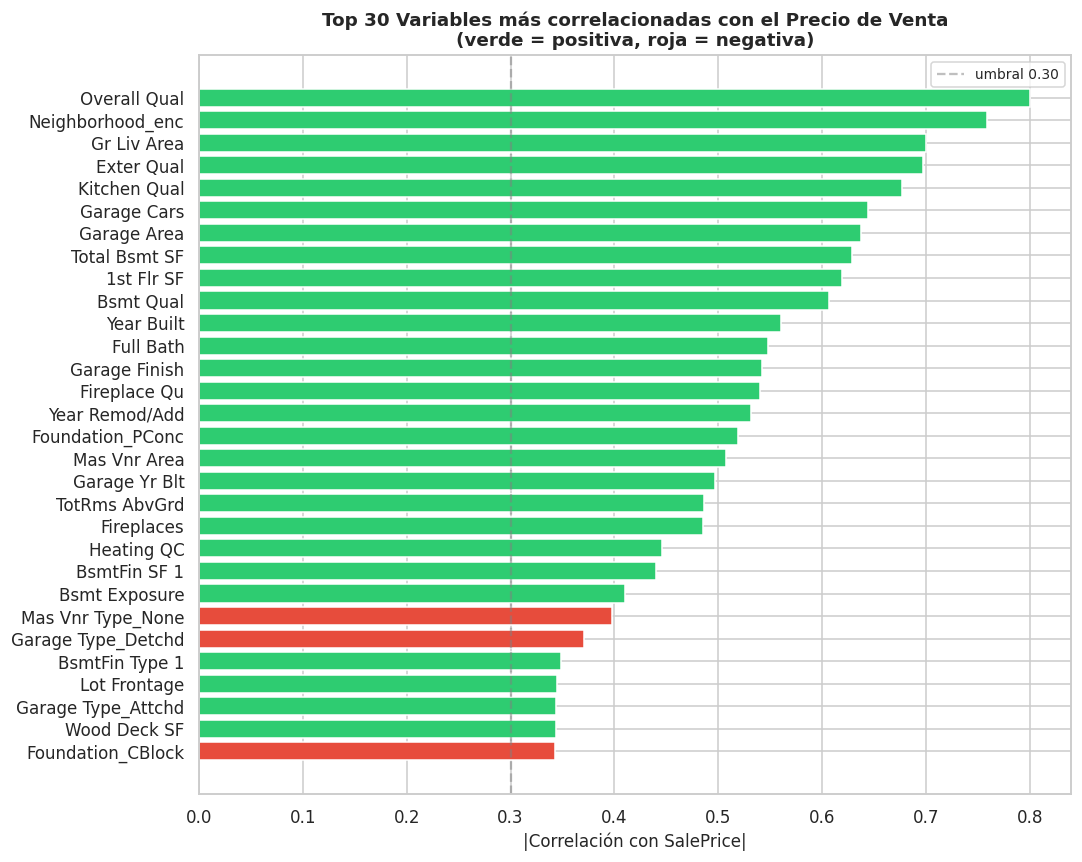

In [14]:
# Top 30 correlaciones con SalePrice (solo variables codificadas)
correlaciones = df_enc.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 8))
colors_corr = ['#2ecc71' if df_enc.corr()['SalePrice'][c] > 0 else '#e74c3c' 
               for c in correlaciones.index]
ax.barh(correlaciones.index[::-1], correlaciones.values[::-1], color=colors_corr[::-1])
ax.set_xlabel('|Correlación con SalePrice|', fontsize=11)
ax.set_title('Top 30 Variables más correlacionadas con el Precio de Venta\n'
             '(verde = positiva, roja = negativa)', 
             fontsize=12, fontweight='bold')
ax.axvline(0.3, color='gray', linestyle='--', alpha=0.5, label='umbral 0.30')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

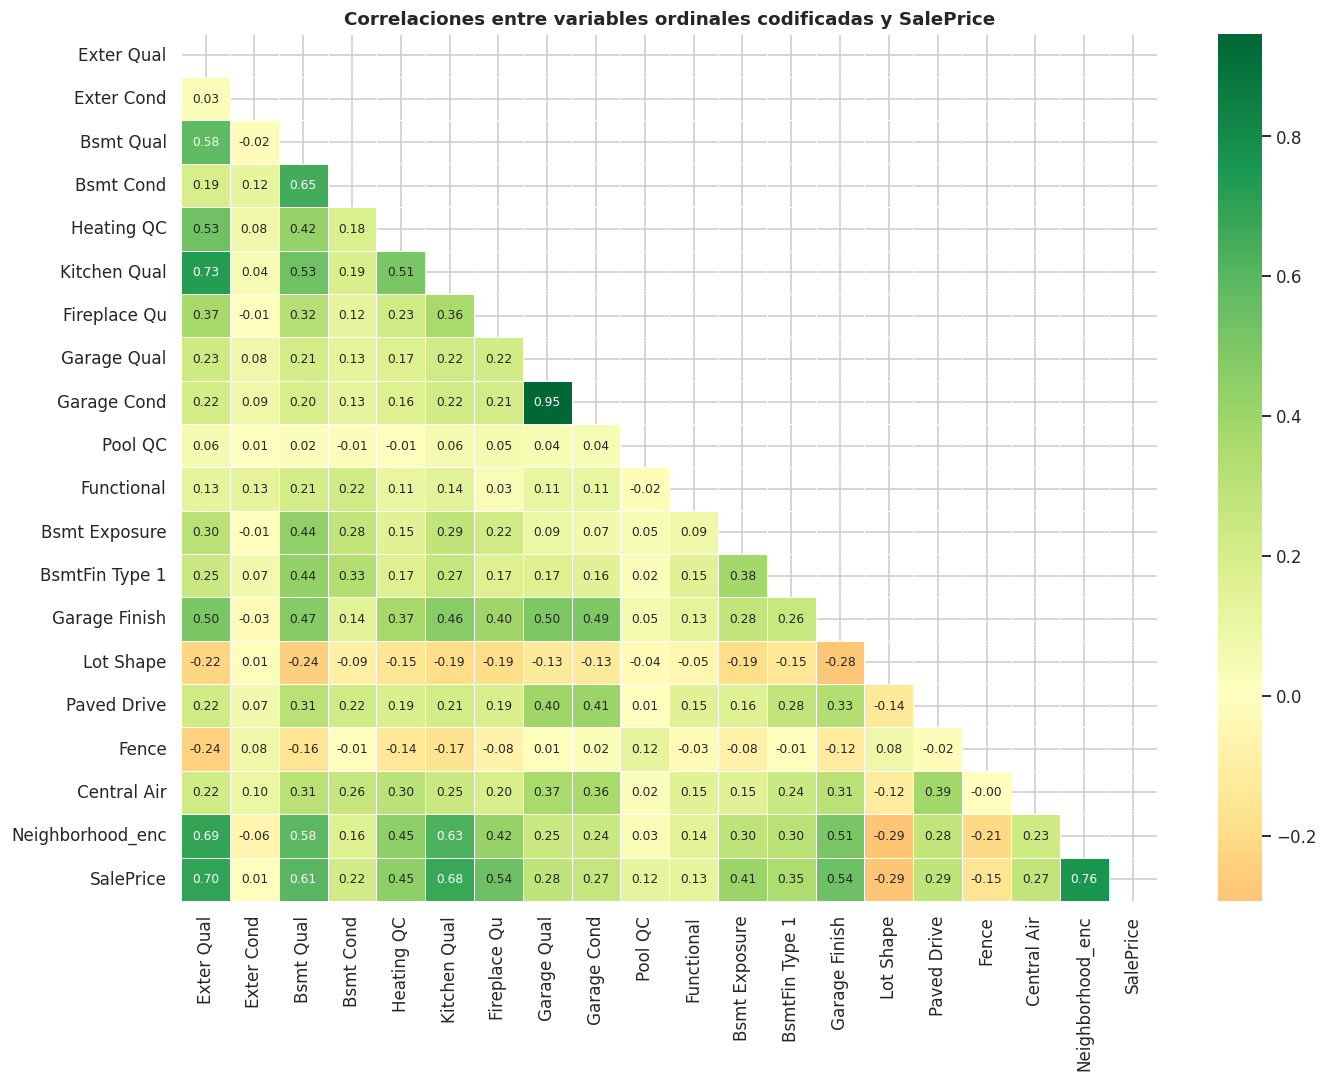

In [15]:
# Heatmap de correlación entre variables ordinales + SalePrice
ord_cols_final = quality_cols + [
    'Functional', 'Bsmt Exposure', 'BsmtFin Type 1', 'Garage Finish',
    'Lot Shape', 'Paved Drive', 'Fence', 'Central Air', 'Neighborhood_enc', 'SalePrice'
]
# Filtrar solo los que existen
ord_cols_final = [c for c in ord_cols_final if c in df_enc.columns]

fig, ax = plt.subplots(figsize=(13, 10))
corr_matrix = df_enc[ord_cols_final].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlaciones entre variables ordinales codificadas y SalePrice',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Resumen de codificaciones aplicadas

In [16]:
resumen_final = pd.DataFrame([
    # Calidad ordinal
    ('Exter Qual', 'Ordinal', 'None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5', round(abs(df_enc['Exter Qual'].corr(df_enc['SalePrice'])), 3)),
    ('Kitchen Qual', 'Ordinal', 'None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5', round(abs(df_enc['Kitchen Qual'].corr(df_enc['SalePrice'])), 3)),
    ('Bsmt Qual', 'Ordinal', 'None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5', round(abs(df_enc['Bsmt Qual'].corr(df_enc['SalePrice'])), 3)),
    ('Fireplace Qu', 'Ordinal', 'None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5', round(abs(df_enc['Fireplace Qu'].corr(df_enc['SalePrice'])), 3)),
    ('Heating QC', 'Ordinal', 'None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5', round(abs(df_enc['Heating QC'].corr(df_enc['SalePrice'])), 3)),
    ('Garage Finish', 'Ordinal', 'None=0, Unf=1, RFn=2, Fin=3', round(abs(df_enc['Garage Finish'].corr(df_enc['SalePrice'])), 3)),
    ('Functional', 'Ordinal', 'Sal=1, Sev=2, ..., Typ=8', round(abs(df_enc['Functional'].corr(df_enc['SalePrice'])), 3)),
    ('Bsmt Exposure', 'Ordinal', 'None=0, No=1, Mn=2, Av=3, Gd=4', round(abs(df_enc['Bsmt Exposure'].corr(df_enc['SalePrice'])), 3)),
    ('BsmtFin Type 1', 'Ordinal', 'None=0, Unf=1, ..., GLQ=6', round(abs(df_enc['BsmtFin Type 1'].corr(df_enc['SalePrice'])), 3)),
    ('Paved Drive', 'Ordinal', 'N=0, P=1, Y=2', round(abs(df_enc['Paved Drive'].corr(df_enc['SalePrice'])), 3)),
    # Binaria
    ('Central Air', 'Binaria', 'N=0, Y=1', round(abs(df_enc['Central Air'].corr(df_enc['SalePrice'])), 3)),
    # Target encoding
    ('Neighborhood_enc', 'Target Enc.', 'Precio mediano del vecindario', round(abs(df_enc['Neighborhood_enc'].corr(df_enc['SalePrice'])), 3)),
    # OHE (muestra)
    ('MS Zoning, Foundation...', 'One-Hot', '20 variables → columnas binarias', '-'),
], columns=['Variable', 'Estrategia', 'Mapeo', '|Corr. SalePrice|'])

print('=== RESUMEN DE CODIFICACIONES ===')
print(resumen_final.to_string(index=False))

=== RESUMEN DE CODIFICACIONES ===
                Variable  Estrategia                                Mapeo |Corr. SalePrice|
              Exter Qual     Ordinal None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5             0.697
            Kitchen Qual     Ordinal None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5             0.677
               Bsmt Qual     Ordinal None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5             0.606
            Fireplace Qu     Ordinal None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5              0.54
              Heating QC     Ordinal None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5             0.446
           Garage Finish     Ordinal          None=0, Unf=1, RFn=2, Fin=3             0.542
              Functional     Ordinal             Sal=1, Sev=2, ..., Typ=8             0.127
           Bsmt Exposure     Ordinal       None=0, No=1, Mn=2, Av=3, Gd=4              0.41
          BsmtFin Type 1     Ordinal            None=0, Unf=1, ..., GLQ=6             0.348
             Paved Drive     Ordinal          

In [17]:
# Guardar el dataset codificado
df_enc.to_csv('ames_encoded.csv', index=False)
print(f'✅ Dataset guardado: ames_encoded.csv')
print(f'   Filas: {df_enc.shape[0]}')
print(f'   Columnas: {df_enc.shape[1]} (todas numéricas)')
print(f'   Listo para usar en regresión lineal, Ridge, Lasso, XGBoost, etc.')

✅ Dataset guardado: ames_encoded.csv
   Filas: 2197
   Columnas: 189 (todas numéricas)
   Listo para usar en regresión lineal, Ridge, Lasso, XGBoost, etc.
